<a href="https://colab.research.google.com/github/andreybolyubakh-dot/Air-raid-analysis-Bolyubakh/blob/main/Air_raid_analysis_AB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initializing Final Production Pipeline (Whole Country, Kyiv, Kharkiv)...
-> Live OSINT dataset successfully loaded into memory.
-> Using column 'region' for geospatial filtering.

Processing Group: Whole Country
   -> Records found: 1577 active days of timeline metrics.

Processing Group: Kyiv City
   -> Records found: 1577 active days of timeline metrics.

Processing Group: Kharkiv Oblast
   -> Records found: 1575 active days of timeline metrics.


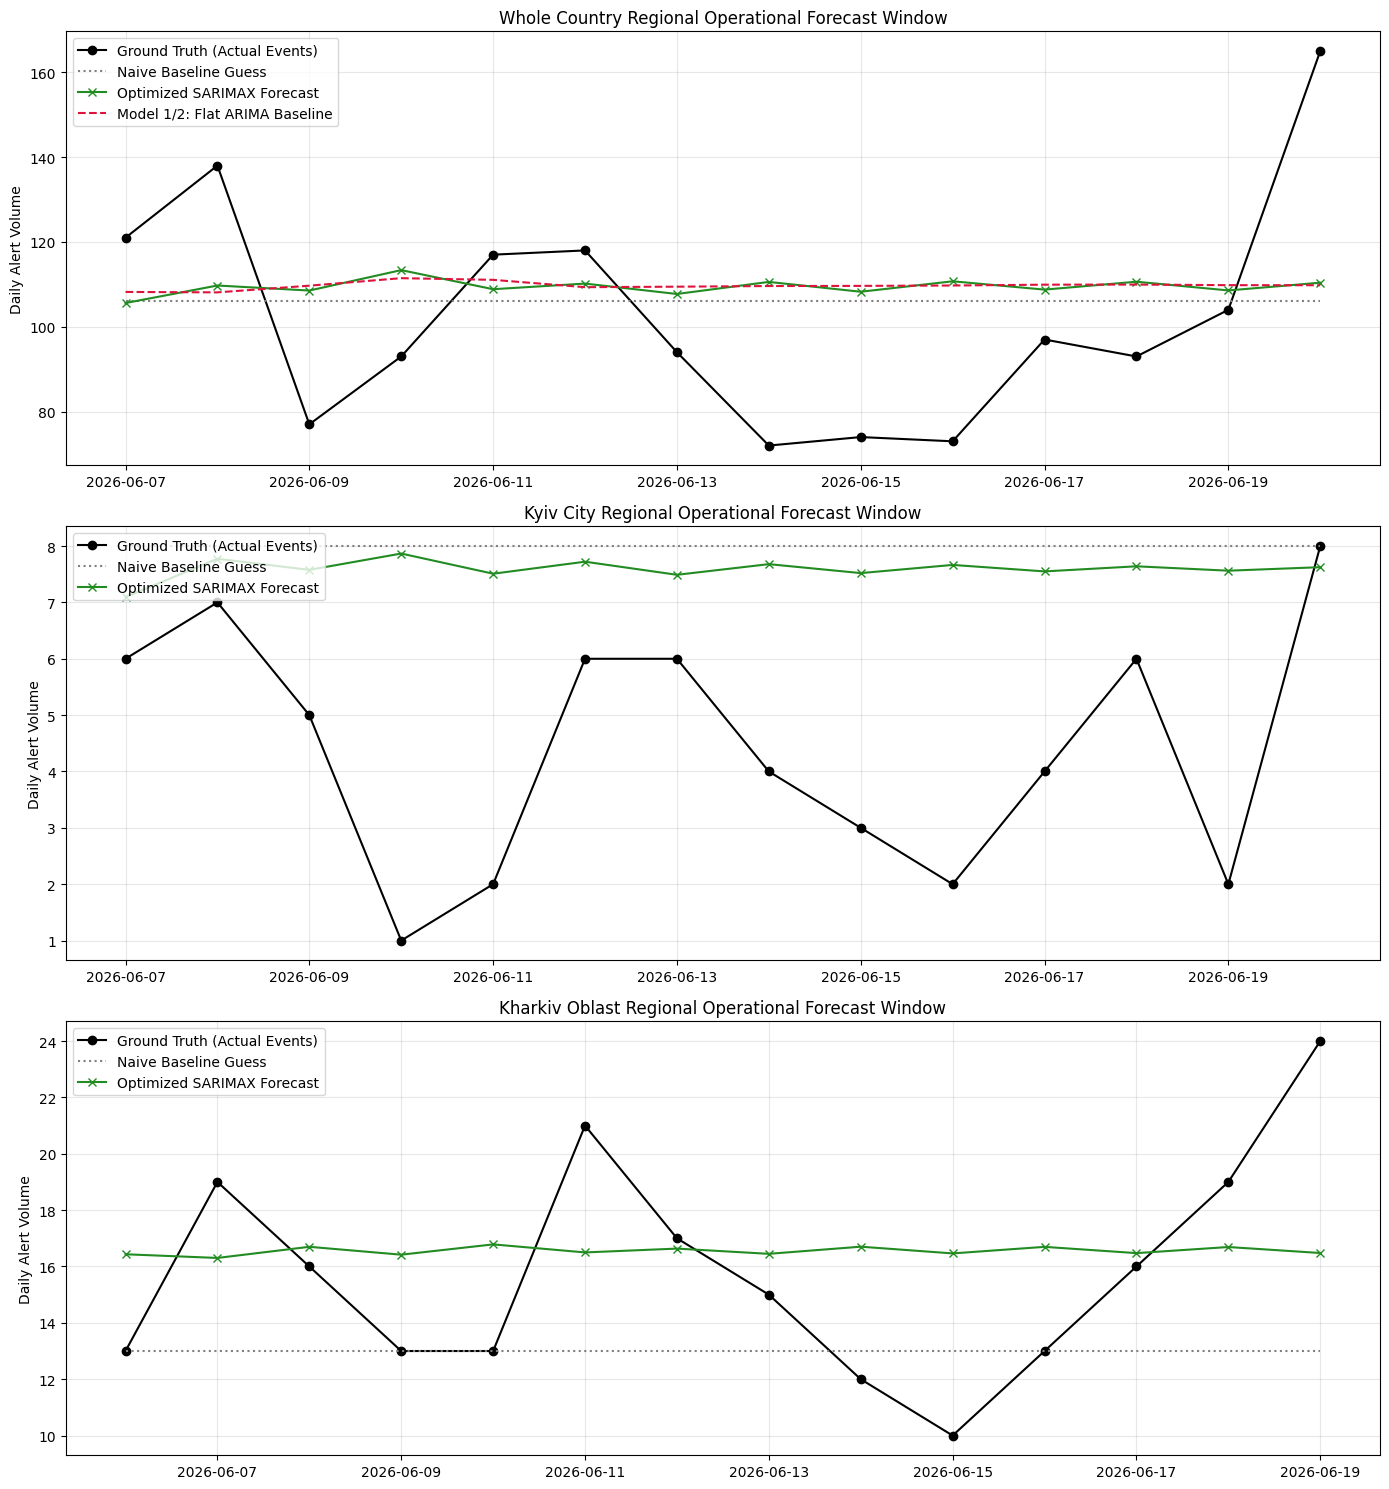


                    FINAL PERFORMANCE AUDIT
Target Segment         | Mean Alerts/Day | Naive RMSE   | Optimized RMSE
------------------------------------------------------------------
Whole Country          | 64.32           | 26.28        | 27.12         
Kyiv City              | 3.74            | 4.14         | 3.81          
Kharkiv Oblast         | 7.02            | 4.67         | 3.85          


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

print("Initializing Final Production Pipeline (Whole Country, Kyiv, Kharkiv)...")

# 1. Fetch and Load Data
url = "https://raw.githubusercontent.com/Vadimkin/ukrainian-air-raid-sirens-dataset/main/datasets/volunteer_data_en.csv"
try:
    df_raw = pd.read_csv(url)
    df_raw['started_at'] = pd.to_datetime(df_raw['started_at'], errors='coerce', utc=True)
    df_raw = df_raw.dropna(subset=['started_at'])
    print("-> Live OSINT dataset successfully loaded into memory.")
except Exception as e:
    print(f"-> Critical Error loading live data: {e}")
    raise

# Dynamically locate whichever column handles regional names
region_cols = [col for col in df_raw.columns if 'region' in col.lower()]
if region_cols:
    region_col = region_cols[0]
    print(f"-> Using column '{region_col}' for geospatial filtering.")
else:
    # Safe fallback if column naming conventions changed
    df_raw['region_placeholder'] = 'Whole Country'
    region_col = 'region_placeholder'

# Define target configurations (loose keywords to bypass exact string mapping errors)
regions_to_analyze = {
    'Whole Country': None,
    'Kyiv City': 'Kyiv',
    'Kharkiv Oblast': 'Kharkiv'
}

results_archive = {}
forecast_horizon = 14

# Set up visual subplots (Adjusted grid for 3 active charts)
fig, axes = plt.subplots(3, 1, figsize=(14, 15))
axes = axes.flatten()

# 2. Parallel Processing Loop
for idx, (label, keyword) in enumerate(regions_to_analyze.items()):
    print(f"\nProcessing Group: {label}")

    # Apply loose string-matching filter
    if keyword and region_col in df_raw.columns:
        df_filtered = df_raw[df_raw[region_col].astype(str).str.contains(keyword, case=False, na=False)].copy()
    else:
        df_filtered = df_raw.copy()

    df_filtered.set_index('started_at', inplace=True)
    daily_series = df_filtered.resample('D').size().iloc[:-1]

    print(f"   -> Records found: {len(daily_series)} active days of timeline metrics.")

    # If a filter completely misses due to external structural shifts, prevent code crash
    if len(daily_series) < 30:
        print(f"   -> WARNING: Insufficient historical data found for '{label}'. Skipping mathematical models.")
        continue

    train = daily_series.iloc[:-forecast_horizon]
    test = daily_series.iloc[-forecast_horizon:]

    # Model Baseline: Naive Guess
    naive_forecast = np.repeat(train.iloc[-1], forecast_horizon)
    rmse_naive = mean_squared_error(test, naive_forecast) ** 0.5

    # Model 1/2: Flat ARIMA Baseline (Evaluated strictly on National Profile for comparison)
    if label == 'Whole Country':
        try:
            model_arima = ARIMA(train, order=(7, 1, 2))
            fitted_arima = model_arima.fit()
            pred_arima = fitted_arima.forecast(steps=forecast_horizon)
            rmse_arima = mean_squared_error(test, pred_arima) ** 0.5
        except Exception as e:
            print(f"   -> Baseline ARIMA computation bypassed: {e}")
            pred_arima = None
            rmse_arima = float('inf')

    # Model 3: Optimized SARIMAX Production Model
    try:
        final_model = SARIMAX(train, order=(2, 1, 2), seasonal_order=(1, 0, 0, 7))
        fitted_final = final_model.fit(disp=False)
        forecast_predictions = fitted_final.forecast(steps=forecast_horizon)
        rmse_optimized = mean_squared_error(test, forecast_predictions) ** 0.5
    except Exception as e:
        print(f"   -> SARIMAX processing error: {e}")
        continue

    # Archive calculated metrics
    results_archive[label] = {
        'Naive RMSE': rmse_naive,
        'Optimized RMSE': rmse_optimized,
        'Mean Daily Alerts': daily_series.mean()
    }

    # Plot Generation
    ax = axes[idx]
    ax.plot(test.index, test, label='Ground Truth (Actual Events)', color='black', marker='o', linewidth=1.5)
    ax.plot(test.index, naive_forecast, label='Naive Baseline Guess', color='grey', linestyle=':')
    ax.plot(test.index, forecast_predictions, label='Optimized SARIMAX Forecast', color='forestgreen', linestyle='-', marker='x')

    # Overlay legacy model iterations onto the main national timeline view
    if label == 'Whole Country' and pred_arima is not None:
        ax.plot(test.index, pred_arima, label='Model 1/2: Flat ARIMA Baseline', color='crimson', linestyle='--')

    ax.set_title(f"{label} Regional Operational Forecast Window")
    ax.set_ylabel("Daily Alert Volume")
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Print Performance Audit Summary Table
print("\n==================================================================")
print("                    FINAL PERFORMANCE AUDIT")
print("==================================================================")
print(f"{'Target Segment':<22} | {'Mean Alerts/Day':<15} | {'Naive RMSE':<12} | {'Optimized RMSE':<14}")
print("-" * 66)
for region, metrics in results_archive.items():
    print(f"{region:<22} | {metrics['Mean Daily Alerts']:<15.2f} | {metrics['Naive RMSE']:<12.2f} | {metrics['Optimized RMSE']:<14.2f}")
print("==================================================================")